In [1]:
!pip install scikit-learn python-opencv-headless tensorflow matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.metrics import accuracy_score, classification_report
from deepface import DeepFace

In [3]:
MIN_FACES = 25

In [4]:
# 1. Load Dataset
print("Loading LFW dataset...")
lfw = fetch_lfw_people(min_faces_per_person=MIN_FACES, resize=1.0)
images = lfw.images
labels = lfw.target
target_names = lfw.target_names
num_classes  = len(np.unique(labels))
print(f"{len(images)} images | {num_classes} classes")
print(f"Image shape: {images[0].shape}")

Loading LFW dataset...
2588 images | 42 classes
Image shape: (125, 94)


In [5]:
#label Encoder
le = LabelEncoder()
labels = le.fit_transform(labels)

In [6]:
print("\nExtracting ArcFace embeddings...")
embeddings   = []
valid_labels = []
failed       = 0

for i, img in enumerate(images):
    img_uint8 = (img * 255).astype(np.uint8)
    img_bgr   = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2BGR)

    try:
        rep = DeepFace.represent(
            img_path=img_bgr,
            model_name="ArcFace",
            enforce_detection=False
        )
        emb = np.array(rep[0]["embedding"])

        #Reject near-zero embeddings
        if np.linalg.norm(emb) > 1e-3:
            embeddings.append(emb)
            valid_labels.append(labels[i])
        else:
            failed += 1

    except Exception as e:
        failed += 1

    if (i + 1) % 200 == 0:
        print(f"  {i+1}/{len(images)} | failed so far: {failed}")

embeddings   = np.array(embeddings)
valid_labels = np.array(valid_labels)

print(f"\nTotal: {len(images)} | Valid: {len(embeddings)} | Failed/dropped: {failed}")
print(f"Embedding shape: {embeddings.shape}")


Extracting ArcFace embeddings...
  200/2588 | failed so far: 0
  400/2588 | failed so far: 0
  600/2588 | failed so far: 0
  800/2588 | failed so far: 0
  1000/2588 | failed so far: 0
  1200/2588 | failed so far: 0
  1400/2588 | failed so far: 0
  1600/2588 | failed so far: 0
  1800/2588 | failed so far: 0
  2000/2588 | failed so far: 0
  2200/2588 | failed so far: 0
  2400/2588 | failed so far: 0

Total: 2588 | Valid: 2588 | Failed/dropped: 0
Embedding shape: (2588, 512)


In [7]:
# 3. L2-Normalize
embeddings_norm = normalize(embeddings, norm='l2')

In [8]:
#  4.Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    embeddings_norm, valid_labels,
    test_size=0.2,
    random_state=42,
    stratify=valid_labels
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (2070, 512) | Test: (518, 512)


In [9]:
# 5. MLP Classifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

def build_mlp(input_dim, num_classes):
    model = Sequential([
        Dense(512, input_shape=(input_dim,)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.3),

        Dense(256),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.2),

        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp = build_mlp(512, num_classes)
mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 42)                  │          10,794 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 407,850 (1.56 MB)

 Trainable params: 406,314 (1.55 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [10]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=5, min_lr=1e-6, verbose=1)
]

In [11]:
print("\nTraining MLP classifier...")
history = mlp.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    callbacks=callbacks
)


Training MLP classifier...
Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8232 - loss: 0.8891 - val_accuracy: 0.5290 - val_loss: 2.7183 - learning_rate: 0.0010
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9758 - loss: 0.1607 - val_accuracy: 0.8629 - val_loss: 1.5465 - learning_rate: 0.0010
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9797 - loss: 0.1093 - val_accuracy: 0.9691 - val_loss: 0.4370 - learning_rate: 0.0010
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9836 - loss: 0.0972 - val_accuracy: 0.9749 - val_loss: 0.1354 - learning_rate: 0.0010
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9797 - loss: 0.0965 - val_accuracy: 0.9788 - val_loss: 0.1019 - learning_rate: 0.0010
Epoch 6/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9797 - loss: 0.0922 - val_accuracy: 0.9826 - val_loss: 0.0928 - learning_rate: 0.0010
Epoch 7/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step -

In [12]:
mlp_acc = accuracy_score(y_test, np.argmax(mlp.predict(X_test), axis=1))
print(f"MLP Test Accuracy: {mlp_acc:.4f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
MLP Test Accuracy: 0.9884


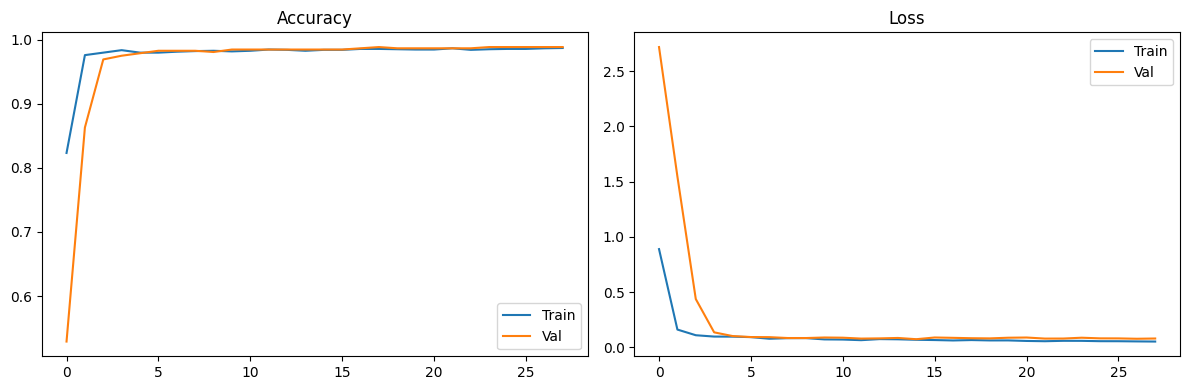

In [13]:
#7. Training Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].legend()
plt.tight_layout()
plt.show()


Predicting first 5 images from dataset...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Image 1
Actual Person:    Gerhard Schroeder
Predicted Person: Gerhard Schroeder
---------------------------


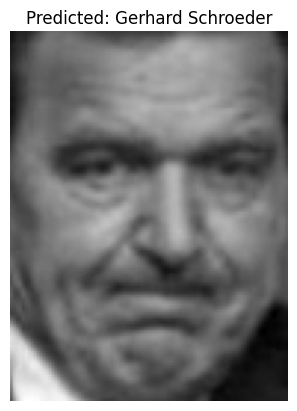

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Image 2
Actual Person:    George W Bush
Predicted Person: George W Bush
---------------------------


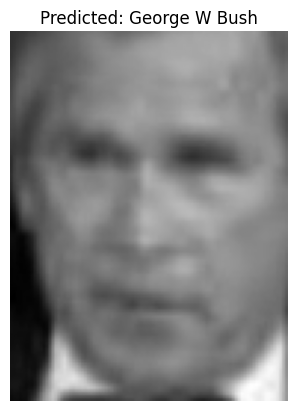

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Image 3
Actual Person:    Vladimir Putin
Predicted Person: Vladimir Putin
---------------------------


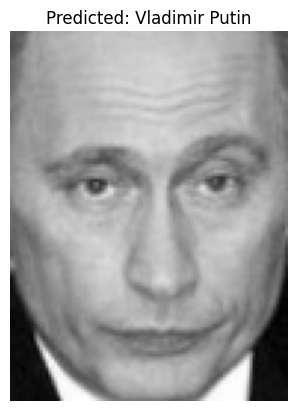

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Image 4
Actual Person:    Colin Powell
Predicted Person: Colin Powell
---------------------------


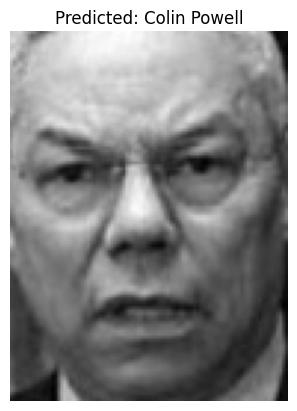

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Image 5
Actual Person:    George W Bush
Predicted Person: George W Bush
---------------------------


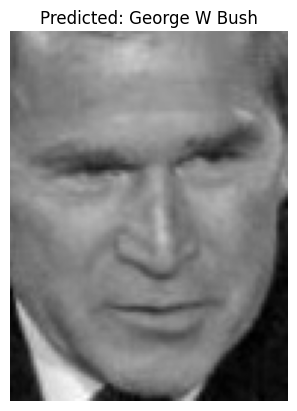

In [14]:
print("\nPredicting first 5 images from dataset...\n")

for i in range(5):

    img = images[i]

    # convert grayscale → uint8 BGR
    img_uint8 = (img * 255).astype(np.uint8)
    img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2BGR)

    # extract embedding
    rep = DeepFace.represent(
        img_path=img_bgr,
        model_name="ArcFace",
        enforce_detection=False
    )

    emb = np.array(rep[0]["embedding"])
    emb = normalize([emb])

    # Prediction using MLP
    pred = np.argmax(mlp.predict(emb), axis=1)[0]

    predicted_name = target_names[pred]
    true_name = target_names[labels[i]]

    print(f"Image {i+1}")
    print("Actual Person:   ", true_name)
    print("Predicted Person:", predicted_name)
    print("---------------------------")

    # Show image
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {predicted_name}")
    plt.axis('off')
    plt.show()